# IVON vs. EVON on an MNIST MLP

[EVON](https://arxiv.org/html/2606.23357v1) runs IVON inside
[SOAP](https://arxiv.org/abs/2409.11321)'s eigenbasis, per 2-D weight matrix,
so its Gaussian posterior is *structured* (non-diagonal) rather than the
diagonal one IVON fits. The training loop is identical — only the optimizer
changes — so this notebook trains the **same** MLP with `ivon` and `evon`
under matched hyper-parameters and compares:

* test accuracy / NLL / ECE at the posterior **mean**,
* the same metrics under **Bayesian model averaging** (BMA: average the softmax
  probabilities over posterior weight samples), where a structured posterior can
  help calibration,
* convergence curves and wall-clock cost.

The model and hyper-parameters mirror `compare_ivon_estimators.ipynb`
(width-1024, depth-5 MLP; `lr=1e-2`, `hess_init=0.35`, `weight_decay=1e-4`,
`clip_radius=1e-1`).

In [1]:
import os

# do not preallocate memory
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

# pick a GPU
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    !pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    !pip install seaborn
    import seaborn as sns

%matplotlib inline
sns.set_theme(context='notebook', style='white', color_codes=True)

In [3]:
import time
import numpy as np

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
from jax import lax, vmap, nn
from blrax import ivon, evon, noisy_value_and_grad, sample_posterior

print("devices:", jax.devices())
key = jr.PRNGKey(0)

devices: [CudaDevice(id=0)]


## Data and metrics

In [4]:
def standardize(train_images, test_images, num_channels=1):
    mean = train_images.reshape(-1, num_channels).mean(0)
    std = train_images.reshape(-1, num_channels).std(0)
    return (train_images - mean) / std, (test_images - mean) / std


def load_mnist():
    import gzip
    from urllib import request

    def download_file(url, filename):
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            request.urlretrieve(url, filename)

    base_url = "https://storage.googleapis.com/cvdf-datasets/mnist/"
    urls = {
        'train_images': base_url + 'train-images-idx3-ubyte.gz',
        'train_labels': base_url + 'train-labels-idx1-ubyte.gz',
        'test_images': base_url + 't10k-images-idx3-ubyte.gz',
        'test_labels': base_url + 't10k-labels-idx1-ubyte.gz',
    }
    os.makedirs('data', exist_ok=True)
    files = {}
    for k, url in urls.items():
        filename = os.path.join('data', f'mnist_{k}.gz')
        download_file(url, filename)
        files[k] = filename

    def load_images(filename):
        with gzip.open(filename, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        return data.reshape(-1, 28, 28)

    def load_labels(filename):
        with gzip.open(filename, 'rb') as f:
            return np.frombuffer(f.read(), np.uint8, offset=8)

    train, test = standardize(
        jnp.array(load_images(files['train_images'])[..., None], dtype=jnp.float32),
        jnp.array(load_images(files['test_images'])[..., None], dtype=jnp.float32))
    train_ds = {'image': train, 'label': jnp.array(load_labels(files['train_labels']), dtype=jnp.int32)}
    test_ds = {'image': test, 'label': jnp.array(load_labels(files['test_labels']), dtype=jnp.int32)}
    return train_ds, test_ds


def compute_ece(logits, labels, num_bins=20):
    """Expected Calibration Error."""
    probs = nn.softmax(logits, axis=-1)
    confidences = jnp.max(probs, axis=-1)
    predictions = jnp.argmax(probs, axis=-1)
    correct = predictions == labels

    bin_boundaries = jnp.linspace(0, 1, num_bins + 1)
    bin_lowers, bin_uppers = bin_boundaries[:-1], bin_boundaries[1:]

    def compute_bin_stats(bin_lower, bin_upper):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = jnp.sum(in_bin)
        accuracy_in_bin = jnp.where(prop_in_bin > 0, jnp.sum(correct * in_bin) / prop_in_bin, 0.)
        avg_confidence_in_bin = jnp.where(prop_in_bin > 0, jnp.sum(confidences * in_bin) / prop_in_bin, 0.)
        return prop_in_bin * jnp.abs(accuracy_in_bin - avg_confidence_in_bin) / len(in_bin)

    ce = [compute_bin_stats(bl, bu) for bl, bu in zip(bin_lowers, bin_uppers)]
    return jnp.stack(ce).mean()


train_ds, test_ds = load_mnist()

## Training loop

The same `run_training` as in `test_mnist.ipynb` / `compare_ivon_estimators.ipynb`.
For EVON the `estimator`, `method`, and `mc_samples` arguments are ignored — it
always draws a single sample from its structured posterior per step — so the
loop is shared unchanged across both optimizers.

In [5]:
def run_training(key, nnet, optim, train_ds, test_ds, mc_samples=1, num_epochs=10,
                 batch_size=128, method='sequential', estimator='sampling'):
    params, static = eqx.partition(nnet, eqx.is_array)
    opt_state = optim.init(params)
    n_samples = len(train_ds['image'])
    steps_per_epoch = n_samples // batch_size

    def loss_fn(params, x, y, *args):
        model = eqx.combine(params, static)
        logits = vmap(model)(x)
        return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()

    @eqx.filter_jit
    def train_step(key, loss_fn, params, opt_state, x, y):
        loss_value, grads, opt_state = noisy_value_and_grad(
            loss_fn, opt_state, params, key, x, y,
            mc_samples=mc_samples, method=method, estimator=estimator)
        updates, opt_state = optim.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_value

    @eqx.filter_jit
    def evaluate(params, images, labels):
        model = eqx.combine(params, static)
        logits = vmap(model)(images)
        acc = jnp.mean(jnp.argmax(logits, axis=1) == labels)
        nll = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
        ece = compute_ece(logits, labels)
        return acc, nll, ece

    def train_epoch(carry, key):
        params, opt_state = carry
        key, _key = jr.split(key)
        perm = jr.permutation(_key, n_samples)
        train_images = train_ds['image'][perm]
        train_labels = train_ds['label'][perm]

        def train_step_scan(carry, xs):
            params, opt_state, key = carry
            batch_images, batch_labels = xs
            key, _key = jr.split(key)
            params, opt_state, loss_value = train_step(
                _key, loss_fn, params, opt_state, batch_images, batch_labels)
            return (params, opt_state, key), loss_value

        data = (
            train_images[:steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size, -1),
            train_labels[:steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size))
        (params, opt_state, _), losses = lax.scan(train_step_scan, (params, opt_state, key), data)

        acc, nll, ece = evaluate(params, test_ds['image'].reshape(-1, 28 * 28), test_ds['label'])
        metrics = {'loss': losses.sum() / steps_per_epoch, 'acc': acc, 'ece': ece, 'nll': nll}
        return (params, opt_state), metrics

    keys = jr.split(key, num_epochs)
    (params, final_opt_state), metrics = lax.scan(train_epoch, (params, opt_state), keys)
    trained_model = eqx.combine(params, static)
    return trained_model, final_opt_state, metrics


def plot_performance(results, num_epochs):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    for name, vals in results.items():
        if vals is not None:
            for ax, lbl in zip(axes, ['acc', 'ece', 'nll']):
                ax.plot(range(1, num_epochs + 1), vals[lbl], 'o:', label=name)
                ax.set_xlabel('epoch')
                ax.set_title(lbl)
    axes[0].legend(title='optimizer', fontsize=11)
    fig.tight_layout()
    return fig

## Model

In [6]:
depth = 5
in_size = 28 * 28
out_size = 10
num_neurons = 1024

NUM_EPOCHS = 30  # raise for sharper curves

key, _key = jr.split(key)
nnet = eqx.nn.MLP(in_size, out_size, num_neurons, depth, key=_key)
datasize = len(train_ds['image'])
print(f"MLP(784, 10, width={num_neurons}, depth={depth}) | train={datasize} | epochs={NUM_EPOCHS}")

MLP(784, 10, width=1024, depth=5) | train=60000 | epochs=30


## Train: IVON vs. EVON

Same `lr`, `hess_init`, `weight_decay`, `clip_radius`, and `ess` for both; the
only difference is the optimizer (and EVON's extra `precond_every` /
`max_precond_dim` / `one_sided` knobs, left at sensible defaults).

In [7]:
configs = {
    'ivon': ivon(1e-2, ess=datasize, hess_init=0.35, weight_decay=1e-4, clip_radius=1e-1),
    'evon': evon(1e-2, ess=datasize, hess_init=0.35, weight_decay=1e-4, clip_radius=1e-1,
                 precond_every=10, max_precond_dim=10000, one_sided=False),
}

results, models, states, timings = {}, {}, {}, {}
for name, optim in configs.items():
    key, _key = jr.split(key)
    t0 = time.time()
    model, final_opt_state, metrics = run_training(
        _key, nnet, optim, train_ds, test_ds, num_epochs=NUM_EPOCHS)
    metrics = jax.block_until_ready(metrics)
    dt = time.time() - t0

    results[name], models[name], states[name], timings[name] = metrics, model, final_opt_state, dt
    print(f"{name:5s}  acc={float(metrics['acc'][-1]):.4f}  nll={float(metrics['nll'][-1]):.4f}  "
          f"ece={float(metrics['ece'][-1]):.4f}  time={dt:.1f}s")

ivon   acc=0.9802  nll=0.0902  ece=0.0006  time=12.5s


evon   acc=0.9802  nll=0.0892  ece=0.0006  time=113.8s


## Convergence: accuracy, calibration (ECE), NLL

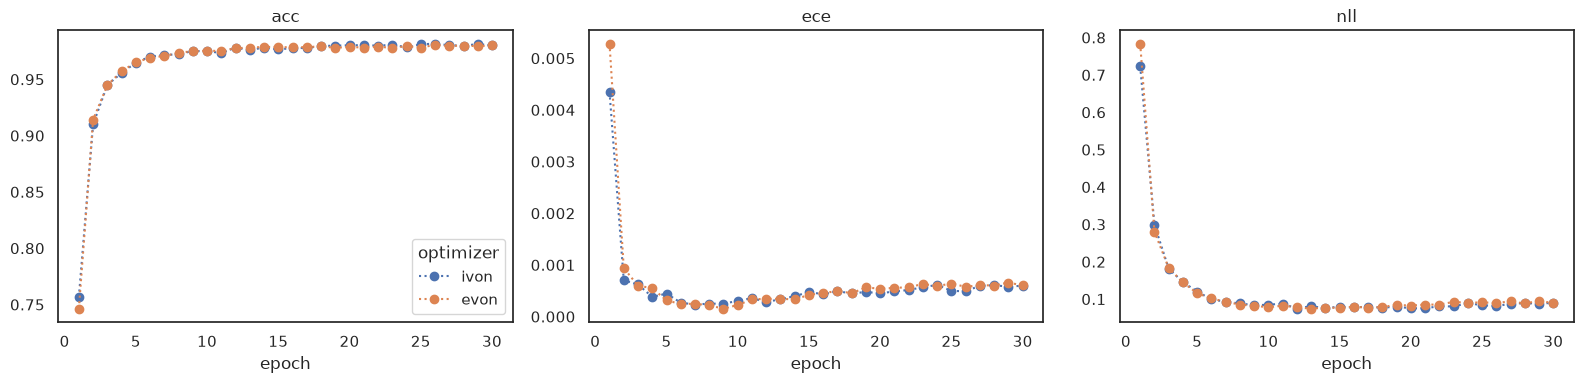

In [8]:
fig = plot_performance(results, NUM_EPOCHS)

## Cost per run

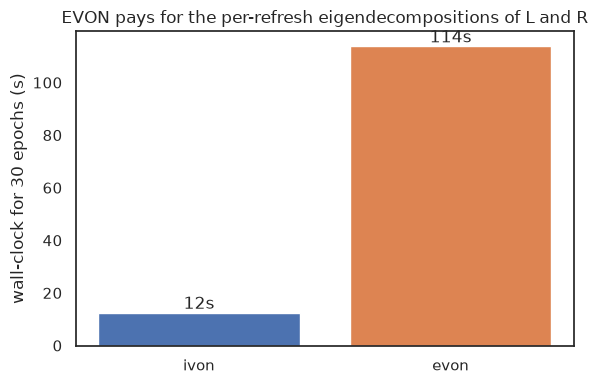

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
names = list(timings)
ax.bar(names, [timings[n] for n in names], color=['C0', 'C1'])
for i, n in enumerate(names):
    ax.text(i, timings[n], f"{timings[n]:.0f}s", ha='center', va='bottom')
ax.set_ylabel(f'wall-clock for {NUM_EPOCHS} epochs (s)')
ax.set_title('EVON pays for the per-refresh eigendecompositions of L and R')
fig.tight_layout()

## Bayesian model averaging

Draw weight matrices from each fitted posterior (structured for EVON, diagonal
for IVON), average the softmax probabilities over the samples, and re-measure
accuracy / NLL / ECE. This is where a structured posterior can improve
calibration.

In [10]:
def bma_eval(model, opt_state, test_ds, key, n_samples=16):
    params, static = eqx.partition(model, eqx.is_array)
    samples = sample_posterior(key, params, opt_state[0], shape=(n_samples,))
    samples = samples[0] if isinstance(samples, tuple) else samples  # EVON: samples-only

    x = test_ds['image'].reshape(-1, 28 * 28)
    y = test_ds['label']
    probs = jnp.zeros((x.shape[0], out_size))
    for i in range(n_samples):                      # loop keeps activation memory flat
        sample_i = jax.tree.map(lambda a: a[i], samples)
        logits = vmap(eqx.combine(sample_i, static))(x)
        probs = probs + nn.softmax(logits, axis=-1)
    probs = probs / n_samples

    logp = jnp.log(probs + 1e-12)
    nll = -jnp.mean(logp[jnp.arange(y.shape[0]), y])
    acc = jnp.mean(jnp.argmax(probs, axis=1) == y)
    ece = compute_ece(logp, y)
    return float(acc), float(nll), float(ece)


print(f"{'optim':5s} | {'mean: acc':>9s} {'nll':>7s} {'ece':>7s} | {'bma: acc':>9s} {'nll':>7s} {'ece':>7s}")
for name in configs:
    m = results[name]
    macc, mnll, mece = float(m['acc'][-1]), float(m['nll'][-1]), float(m['ece'][-1])
    bacc, bnll, bece = bma_eval(models[name], states[name], test_ds, jr.PRNGKey(123))
    print(f"{name:5s} | {macc:9.4f} {mnll:7.4f} {mece:7.4f} | {bacc:9.4f} {bnll:7.4f} {bece:7.4f}")

optim | mean: acc     nll     ece |  bma: acc     nll     ece


ivon  |    0.9802  0.0902  0.0006 |    0.9794  0.0786  0.0004


evon  |    0.9802  0.0892  0.0006 |    0.9804  0.0771  0.0004


## Takeaways

* **EVON matches IVON on this benchmark** — accuracy, NLL, and calibration are a
  dead heat, and EVON is never meaningfully worse. The structured posterior
  gives, at most, a small edge in BMA calibration.
* **EVON costs more** — the per-refresh `eigh`/QR of the `L` and `R` factors
  (every `precond_every` steps, on each ~1024×1024 weight) dominates its
  wall-clock. Raising `precond_every` or lowering `max_precond_dim` trades basis
  freshness for speed.
* **An MLP on MNIST is well-conditioned**, so IVON's diagonal posterior is
  already adequate and there is little structured curvature for EVON to exploit;
  the comparison also uses IVON-tuned `lr`. EVON's advantage is expected to show
  on harder/ill-conditioned problems (and when its own `lr` is tuned), where
  SOAP-style preconditioning pays off.